In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [6]:
#task_ids = ["task-1", "task-2", "task-3", "task-4"]
task_ids = ["task-5", "task-6", "task-7", "task-8"]

metrics_table = pl.concat(
    [
        pl.read_csv(f"{task_id}/metrics.csv").with_columns(task_id=pl.lit(task_id))
        for task_id in task_ids
    ]
)
metrics_table = metrics_table.sort("task_id", "config_id")

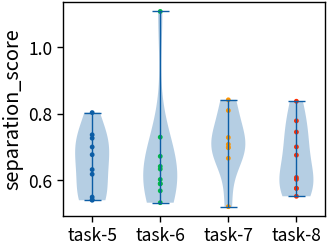

In [7]:
metric_key = "separation_score"

fig, ax = plt.subplots(figsize=(1.7, 1.3))

data = []
for task_id in task_ids:
    section = metrics_table.filter(pl.col("task_id") == task_id)
    data.append(section[metric_key])

xs = np.arange(len(task_ids))

ax.violinplot(data, positions=xs)

for x, y in zip(xs, data):
    ax.scatter(np.full_like(y, x), y, s=3)

ax.set_xticks(xs)
ax.set_xticklabels(task_ids)
ax.set_ylabel(metric_key)

pass

In [8]:
target_key = "separation_score"

for (task_id,), group in metrics_table.group_by("task_id"):
    target_score = group[target_key].median()

    sorted_group = group.sort(
        (pl.col(target_key) - target_score).abs()
    )
    print(task_id, "->", sorted_group[0, "config_id"], "...", sorted_group[0, target_key])

task-5 -> 6 ... 0.632376803530301
task-6 -> 5 ... 0.6026588775471144
task-7 -> 0 ... 0.699475455070202
task-8 -> 1 ... 0.6086456898671254
